# CS 1090B Milestone 4 Main Notebook: plant-geopriors

**Canvas Project Number:** 49  
**Group Members:** Ceci Zhang; Manini Banerjee; Neha Sajja  
**Project:** plant-geopriors

## Project Overview

This project studies whether geographic and seasonal metadata can improve fine-grained plant species classification beyond image-only recognition. Citizen-science platforms such as iNaturalist contain millions of plant observations with photographs, GPS coordinates, and timestamps. The image is the most obvious signal, but plants also have ecological ranges and seasonal patterns, so latitude, longitude, and day-of-year can act as useful priors.

Our task is a 44-way species classification problem focused on morphologically challenging California plants from Asteraceae, Poaceae, and Apiaceae. These families include many species that are visually similar in field photographs, such as small yellow composites, grasses, and umbel-bearing species. The central question is: when the image alone is ambiguous, can geo/time context help the classifier make a better prediction?

## Modeling Strategy

The project compares several models that use the same class mapping and held-out evaluation splits where appropriate:

- **Image-only ResNet50 baseline:** a fine-tuned CNN that predicts species from the observation image.
- **Geo/time MLP baseline:** a small neural network trained on six sinusoidal latitude, longitude, and day-of-year features.
- **Weighted-addition fusion:** a late-fusion method that combines image logits and geo/time logits using validation-selected weights.
- **Expanded geo/time baseline:** a geo model trained with additional location/season observations beyond the image-aligned subset.
- **Fusion MLP final model:** the final model for this submission, trained on concatenated logits from the frozen image model and expanded geo/time model.

The main reported metric is test-set top-1 accuracy, with balanced accuracy, per-species accuracy, confusion matrices, and error-analysis plots used to understand where fusion helps or hurts.

## What This Notebook Does

The notebook loads the processed data artifacts, rebuilds the evaluation inputs, loads saved checkpoints, evaluates the baseline models, evaluates the weighted-addition model, and reports the final Fusion MLP results end-to-end.

The longer data collection, species selection, exploratory analysis, and training work remains in the supporting notebooks. To keep this notebook fast in Colab or on a CPU-only machine, the default path uses saved checkpoints and cached logits rather than retraining models or re-running the full ResNet50 image pass.


## 1. Setup

Dependencies are listed in `requirements.txt` at the project root. The next cell is intentionally lightweight: it does not force-install packages every time, but it shows the command to run if a fresh Colab or local environment is missing dependencies.

The notebook can run in either Google Colab or a local Jupyter environment:

- In Colab, place or clone this submission folder so that `artifacts/`, `checkpoints/`, `results/`, and `requirements.txt` are in the same project root. If the folder is on Google Drive, the setup cell will mount Drive and search common Drive locations.
- Locally, open the notebook from either the project root or the `notebooks/` folder. The setup code walks upward from the current working directory to find the project root.

Expected folder layout:

- `artifacts/`: processed data tables, label encoder, split files, and cached logits.
- `checkpoints/`: trained model checkpoints.
- `results/`: final figures and result summaries.
- `data/images/`: optional raw images, only needed if cached logits must be recomputed.


In [1]:
# Optional dependency install for a fresh runtime.
# Run this cell after uncommenting the command if imports fail.
# In Colab, this will usually work when the notebook is inside this submission folder.
# %pip install -q -r ../requirements.txt


## AI Use And Citation Note

OpenAI Codex (GPT-5) was used on 9 May 2026 as a coding and organization assistant for this submission package. Its assistance was limited to organizing this main notebook, creating the submission-folder structure, adding checkpoint-first evaluation code, and generating the cached Fusion MLP logits file from the team's existing checkpoints. The project question, data collection, modeling approach, checkpoints, supporting notebooks, interpretation, and final model choice are the group's work. The group reviewed and executed this notebook after the AI-assisted edits.

This disclosure is repeated in the references section following the course citation policy and MLA guidance for acknowledging generative AI assistance.


### Imports, Seeds, And Project Paths

All paths are resolved relative to the project root. This avoids machine-specific paths and lets the notebook run from either the repository root or the `notebooks/` directory.

In [2]:
import os
import sys
import json
import random
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    if os.environ.get("CANOPY_SKIP_DRIVE_MOUNT", "0") != "1":
        drive.mount("/content/drive", force_remount=False)

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms
from PIL import Image

from sklearn.metrics import confusion_matrix, classification_report

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)


def find_project_root():
    """Find the folder containing artifacts/, checkpoints/, and results/."""
    candidates = []

    override = os.environ.get("CANOPY_PROJECT_ROOT")
    if override:
        candidates.append(Path(override).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    if IN_COLAB:
        candidates.extend([
            Path("/content/drive/MyDrive/Final_project_109B")
        ])

    seen = set()
    for candidate in candidates:
        candidate = candidate.expanduser().resolve()
        if candidate in seen:
            continue
        seen.add(candidate)
        if (
            (candidate / "artifacts").exists()
            and (candidate / "checkpoints").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    searched = "\n".join(str(c) for c in candidates)
    raise FileNotFoundError(
        "Could not locate the project root containing artifacts/, checkpoints/, and results/. "
        "Set CANOPY_PROJECT_ROOT to the submission folder if needed.\n\nSearched:\n"
        + searched
    )


PROJECT_ROOT = find_project_root()
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = DATA_DIR / "images"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Running in Colab: {IN_COLAB}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DEVICE: {DEVICE}")


Running in Colab: False
PROJECT_ROOT: /Users/wenchuzhang/Documents/Graduate/Harvard/CS 109B/Project/Canopy/submission_group49_plant_geopriors
DEVICE: mps


### Required Files

This cell checks that the processed artifacts and checkpoints needed for the fast end-to-end run are present. 

In [3]:
REQUIRED_FILES = {
    "master_df": ARTIFACTS_DIR / "master_df_img_and_geo.csv",
    "master_observations": ARTIFACTS_DIR / "master_observations.csv",
    "split_iid": ARTIFACTS_DIR / "split_iid.csv",
    "expanded_geo": ARTIFACTS_DIR / "master_observations_geo_expanded.csv",
    "split_geo_expanded": ARTIFACTS_DIR / "split_geo_expanded.csv",
    "label_encoder": ARTIFACTS_DIR / "label_encoder.pkl",
    "weighted_logits": CHECKPOINTS_DIR / "weighted_addition_logits.pth",
    "fusion_logits": ARTIFACTS_DIR / "fusion_mlp_logits_expanded.pth",
    "geo_ckpt": CHECKPOINTS_DIR / "geo_baseline.pth",
    "geo_expanded_ckpt": CHECKPOINTS_DIR / "geo_baseline_expanded.pth",
    "resnet_ckpt": CHECKPOINTS_DIR / "resnet50_finetune.pth",
    "fusion_ckpt": CHECKPOINTS_DIR / "fusion_mlp.pth",
}

missing = [name for name, path in REQUIRED_FILES.items() if not path.exists()]
if missing:
    raise FileNotFoundError({name: str(REQUIRED_FILES[name]) for name in missing})

print("All required artifacts/checkpoints are present.")
print(f"Raw image folder exists: {IMAGES_DIR.exists()} ({IMAGES_DIR})")

All required artifacts/checkpoints are present.
Raw image folder exists: True (/Users/wenchuzhang/Documents/Graduate/Harvard/CS 109B/Project/Canopy/submission_group49_plant_geopriors/data/images)


## 2. Load Processed Data And EDA

This section loads the processed tables that feed each part of the final modeling pipeline. The raw observations come from a California-restricted GBIF / iNaturalist 2025 export covering three plant families: Asteraceae, Poaceae, and Apiaceae. We first filtered to species with enough observations and enough seasonal/geographic spread to support both image and geo/time modeling; the final label space contains 44 species.

Species selection was based on the EDA and comparison work in `01_eda.ipynb` and `04_species_comparison.ipynb`. We compared three procedural shortlisting strategies: raw observation count (`top_n`), seasonal coverage (`time_diverse`), and joint temporal-spatial diversity using k-means over `(lat, lon, doy)` (`time_geo_diverse`). The final pipeline uses the temporal-spatial strategy because it spreads training examples across each species range instead of concentrating too heavily around high-observation hotspot counties.

The project keeps two aligned working datasets with the same 44-class label space:

- **Image-backed dataset:** 4,400 observations where every row has an associated image. This is the dataset used by the ResNet50 image baseline, the original geo/time baseline, weighted-addition fusion, and the cached logits used by the Fusion MLP evaluation path. Its IID split is 3,080 train / 660 validation / 660 test.
- **Expanded geo/time dataset:** 103,314 observations used for the expanded geo baseline. It preserves the original 4,400 image-backed split assignments exactly to avoid leakage, then stratifies the additional 98,914 image-less observations by species. Its split sizes are 72,319 train / 15,497 validation / 15,498 test.

The six geo/time features are derived from raw latitude, longitude, and day-of-year using sinusoidal encodings:

`lat_sin/cos = sin/cos(pi * lat / 90)`  
`lon_sin/cos = sin/cos(pi * lon / 180)`  
`doy_sin/cos = sin/cos(pi * (doy - 183) / 183)`

We used this encoding because the raw numeric scales have artificial edges. For example, day 365 and day 1 are far apart numerically but close seasonally, and longitude/latitude also represent cyclic or bounded geographic structure more naturally than a simple linear scale. Future work could compare these encodings with learned spatial embeddings or other geographic feature transforms.

In [4]:
# `master_df_img_and_geo.csv` is the main image-aligned modeling table. It contains one row per image-backed
# observation and is used by the ResNet50 image baseline, original geo/time baseline, weighted-addition model, 
# and Fusion MLP cache.
master_df = pd.read_csv(ARTIFACTS_DIR / "master_df_img_and_geo.csv")

# `master_observations.csv` is the cleaned observation table before the final split/feature additions. We keep
#  it loaded for transparency and sanity checks against the processed modeling table.
master_observations = pd.read_csv(ARTIFACTS_DIR / "master_observations.csv")

#`split_iid.csv` records the shared IID split assignment for the image-backed dataset. This keeps image-only, 
#geo-only, and weighted-addition validation/test results comparable.
split_iid = pd.read_csv(ARTIFACTS_DIR / "split_iid.csv")


# `master_observations_geo_expanded.csv` and `split_geo_expanded.csv` support the expanded geo/time baseline 
# and provide the geo backbone used by the final Fusion MLP.
expanded_geo_df = pd.read_csv(ARTIFACTS_DIR / "master_observations_geo_expanded.csv")
split_geo_expanded = pd.read_csv(ARTIFACTS_DIR / "split_geo_expanded.csv")

le = joblib.load(ARTIFACTS_DIR / "label_encoder.pkl")

GEO_FEATURE_COLS = ["lat_sin", "lat_cos", "lon_sin", "lon_cos", "doy_sin", "doy_cos"]
GEO_TARGET_COL = "label_species"
NUM_CLASSES = len(le.classes_)

# Replace machine-specific image paths with project-relative paths when possible.
def relative_image_path(row):
    species_dir = str(row["species"]).replace(" ", "_")
    return IMAGES_DIR / species_dir / f"{row['gbifID']}.jpg"

master_df["image_path_relative"] = master_df.apply(relative_image_path, axis=1)

train_df = master_df[master_df["split_iid"] == "train"].reset_index(drop=True)
val_df = master_df[master_df["split_iid"] == "val"].reset_index(drop=True)
test_df = master_df[master_df["split_iid"] == "test"].reset_index(drop=True)

print(f"Image-aligned observations: {master_df.shape}")
print(f"IID split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(f"Expanded geo observations: {expanded_geo_df.shape}")
print(f"Number of species/classes: {NUM_CLASSES}")

display(master_df[["gbifID", "species", "decimalLatitude", "decimalLongitude", "doy", "split_iid", GEO_TARGET_COL]].head())

Image-aligned observations: (4400, 17)
IID split sizes: train=3080, val=660, test=660
Expanded geo observations: (103314, 14)
Number of species/classes: 44


,gbifID,species,decimalLatitude,decimalLongitude,doy,split_iid,label_species
0,5166817590,Bromus rubens,33.598145,-117.762550,89,train,12
1,4945552183,Centaurea solstitialis,39.488280,-121.882562,283,train,14
2,4133841801,Sanicula crassicaulis,41.055678,-124.149876,182,train,40
3,4145438206,Daucus carota,40.946515,-124.100620,212,train,20
4,3988626971,Arundo donax,33.969371,-117.436306,362,train,6


### Compact EDA Summary

This cell gives a compact EDA checkpoint for the final notebook: split balance, class balance, and geographic coverage. The fuller exploratory work lives in the supporting notebooks.


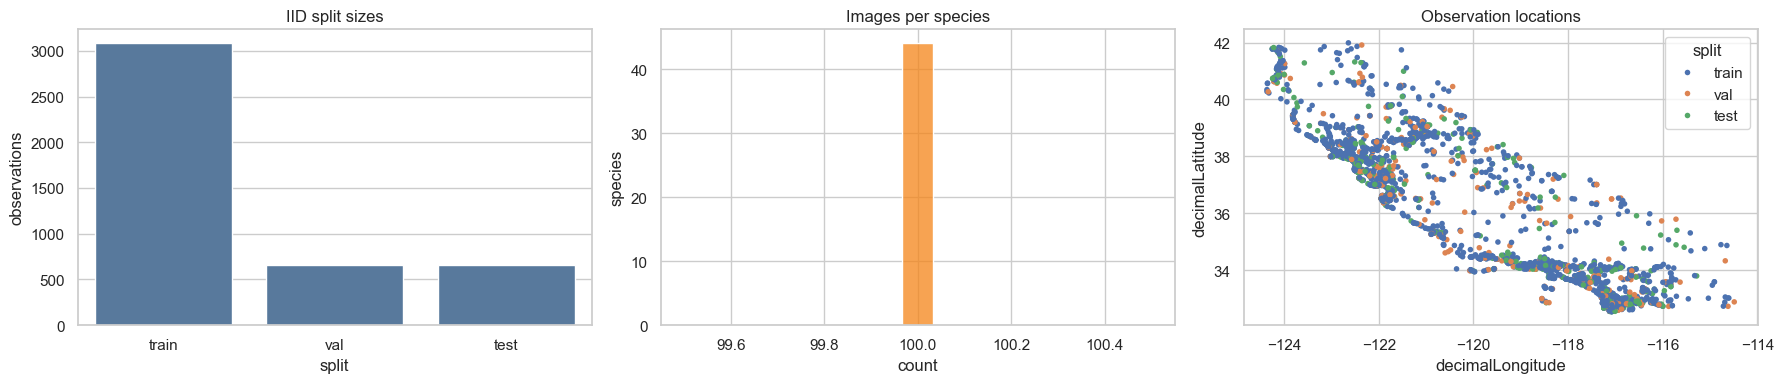

,species_count
split_iid,
test,44
train,44
val,44


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

split_counts = master_df["split_iid"].value_counts().reindex(["train", "val", "test"])
sns.barplot(x=split_counts.index, y=split_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("IID split sizes")
axes[0].set_xlabel("split")
axes[0].set_ylabel("observations")

species_counts = master_df["species"].value_counts().sort_values(ascending=False)
sns.histplot(species_counts.values, bins=15, ax=axes[1], color="#F58518")
axes[1].set_title("Images per species")
axes[1].set_xlabel("count")
axes[1].set_ylabel("species")

sns.scatterplot(
    data=master_df.sample(min(len(master_df), 2500), random_state=RANDOM_STATE),
    x="decimalLongitude",
    y="decimalLatitude",
    hue="split_iid",
    s=16,
    linewidth=0,
    ax=axes[2],
)
axes[2].set_title("Observation locations")
axes[2].legend(title="split", loc="best")

plt.tight_layout()
plt.show()

display(master_df.groupby("split_iid")["species"].nunique().rename("species_count").to_frame())

### Dataset Utilities

The final run uses cached logits, but the dataset class remains here so the notebook contains the actual image + geo evaluation path. If `artifacts/fusion_mlp_logits_expanded.pth` is missing and `data/images/` is available, the same notebook can recompute logits from the frozen checkpoints.

In [6]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class PlantMultimodalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row["image_path_relative"])
        if not image_path.exists():
            image_path = Path(row["image_path"])
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        geo_features = torch.tensor(row[GEO_FEATURE_COLS].values.astype(np.float32), dtype=torch.float32)
        label = torch.tensor(int(row[GEO_TARGET_COL]), dtype=torch.long)
        return image, geo_features, label


def to_geo_tensors(df):
    X = torch.tensor(df[GEO_FEATURE_COLS].values, dtype=torch.float32)
    y = torch.tensor(df[GEO_TARGET_COL].values, dtype=torch.long)
    return X, y

X_val_geo, y_val_geo = to_geo_tensors(val_df)
X_test_geo, y_test_geo = to_geo_tensors(test_df)
print(f"Geo tensor shapes: val={tuple(X_val_geo.shape)}, test={tuple(X_test_geo.shape)}")

Geo tensor shapes: val=(660, 6), test=(660, 6)


## 3. Model Definitions And Checkpoint Loading
- **Image-Only Baseline** 
A torchvision ResNet50 initialized with ImageNet weights, frozen except for a replaced final fully-connected layer of dimension 2048 → 44. Training uses standard ImageNet augmentations, weighted cross-entropy on the inverse capped frequencies, and Adam at lr = 1e-3. 
- **Geo_model Baseline**
A four-layer MLP with three hidden blocks of width 256, ReLU activations and dropout 0.3, mapping the six geo/time features to 44 logits. Trained on the expanded 103k-row split (validation accuracy 13.8%). Per-species behavior is strikingly uneven: Sanicula arctopoides reaches 67% top-1, while 21 of 44 species sit at 0%. 
- **Weighted-Addition Fusion**
Both baselines are loaded frozen. We compute: final_logits = α · image_logits + β · context_logits, sweeping β ∈ [0, 1] on a 21-point grid with α = 1 − β on the validation split. The chosen (α, β) is then evaluated once on the test split. This model has zero trainable parameters; it is a calibration of how much the geographic prior should shift the visual posterior. The selected weights favor the image side, with a small boost from context. This approach is directly motivated by the Bayesian factorization P(y|I, x) ∝ P(y|I) · P(y|x) from Mac Aodha et al. (2019), which justifies combining image and geographic posteriors independently.
- **Trainable Fusion MLP**
A single hidden-layer head over concatenated baseline logits: R^88 → Linear → R^256 → ReLU, Dropout → R^44. Both backbones are frozen; only the head trains. Training operates on pre-cached logit tensors over the image-having rows, with batch size 256, Adam at lr = 1e-3, per-epoch per-species capping at 500, and early stopping on validation balanced accuracy (best epoch 17 of a 30-epoch budget). Because backbones are frozen and the input is 88-dimensional, the head is small (~25k parameters) and trains in seconds


These are the checkpoint-compatible definitions used in the supporting notebooks. We load each trained checkpoint here to verify that the final notebook is connected to the saved models, even though the fast evaluation below uses cached logits for speed.

In [7]:
def torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

class GeoBaseline(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.network(x)

class FusionMLP(nn.Module):
    def __init__(self, cnn_dim=44, geo_dim=44, hidden_dim=256, num_classes=44, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cnn_dim + geo_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, cnn_logits, geo_logits):
        return self.net(torch.cat([cnn_logits, geo_logits], dim=1))


def build_resnet50(num_classes):
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def best_state(ckpt):
    return ckpt.get("best_model_state", ckpt.get("model_state", ckpt))

geo_model = GeoBaseline(NUM_CLASSES).to(DEVICE)
geo_model.load_state_dict(best_state(torch_load(CHECKPOINTS_DIR / "geo_baseline.pth", DEVICE)))
geo_model.eval()

geo_expanded_model = GeoBaseline(NUM_CLASSES).to(DEVICE)
geo_expanded_model.load_state_dict(best_state(torch_load(CHECKPOINTS_DIR / "geo_baseline_expanded.pth", DEVICE)))
geo_expanded_model.eval()

resnet_model = build_resnet50(NUM_CLASSES).to(DEVICE)
resnet_model.load_state_dict(best_state(torch_load(CHECKPOINTS_DIR / "resnet50_finetune.pth", DEVICE)))
resnet_model.eval()

fusion_model = FusionMLP(cnn_dim=NUM_CLASSES, geo_dim=NUM_CLASSES, hidden_dim=256, num_classes=NUM_CLASSES).to(DEVICE)
fusion_model.load_state_dict(best_state(torch_load(CHECKPOINTS_DIR / "fusion_mlp.pth", DEVICE)))
fusion_model.eval()

for model in [geo_model, geo_expanded_model, resnet_model, fusion_model]:
    for p in model.parameters():
        p.requires_grad_(False)

print("Loaded checkpoints: geo baseline, expanded geo baseline, ResNet50 image baseline, Fusion MLP.")

Loaded checkpoints: geo baseline, expanded geo baseline, ResNet50 image baseline, Fusion MLP.


## 4. Evaluation Helpers

We report both ordinary accuracy and balanced accuracy. Balanced accuracy is important here because every species is a class and the expanded geo data can be imbalanced.

In [8]:
def accuracy_from_preds(preds, labels):
    return (preds == labels).float().mean().item()


def balanced_accuracy_from_preds(preds, labels, num_classes=NUM_CLASSES):
    per_class = []
    for c in range(num_classes):
        mask = labels == c
        if mask.any():
            per_class.append((preds[mask] == labels[mask]).float().mean().item())
    return float(np.mean(per_class))


def metrics_from_logits(logits, labels, name):
    labels = labels.cpu().long()
    logits = logits.cpu()
    preds = logits.argmax(dim=1)
    loss = nn.CrossEntropyLoss()(logits, labels).item()
    return {
        "name": name,
        "loss": loss,
        "accuracy": accuracy_from_preds(preds, labels),
        "balanced_accuracy": balanced_accuracy_from_preds(preds, labels),
        "preds": preds,
        "labels": labels,
        "logits": logits,
    }


def metrics_from_preds(preds, labels, name):
    preds = preds.cpu().long()
    labels = labels.cpu().long()
    return {
        "name": name,
        "loss": np.nan,
        "accuracy": accuracy_from_preds(preds, labels),
        "balanced_accuracy": balanced_accuracy_from_preds(preds, labels),
        "preds": preds,
        "labels": labels,
    }


def per_species_accuracy(metrics):
    rows = []
    preds = metrics["preds"]
    labels = metrics["labels"]
    for label, name in enumerate(le.classes_):
        mask = labels == label
        total = int(mask.sum().item())
        correct = int((preds[mask] == label).sum().item()) if total else 0
        rows.append({"label": label, "species": name, "correct": correct, "total": total, "accuracy": correct / total if total else np.nan})
    return pd.DataFrame(rows)


def plot_confusion(metrics, title, max_classes=None):
    labels = metrics["labels"].numpy()
    preds = metrics["preds"].numpy()
    cm = confusion_matrix(labels, preds, labels=np.arange(NUM_CLASSES), normalize="true")
    fig_w = 12 if max_classes is None else 8
    plt.figure(figsize=(fig_w, fig_w))
    sns.heatmap(cm, cmap="Blues", square=True, cbar_kws={"label": "recall"})
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.show()


def show_result_image(filename, title=None):
    path = RESULTS_DIR / filename
    if not path.exists():
        print(f"Missing result image: {path}")
        return
    img = Image.open(path)
    plt.figure(figsize=(12, min(10, 12 * img.height / img.width)))
    plt.imshow(img)
    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

## 5. Baseline Results From Cached Logits

The weighted-addition notebook cached ResNet50 image logits and the original geo/time baseline logits for the validation and test splits. We use that cache to report the two core baselines and the weighted-addition model without re-running the image backbone.

In [9]:
weighted_cache = torch_load(CHECKPOINTS_DIR / "weighted_addition_logits.pth", "cpu")
assert list(weighted_cache["class_names"]) == list(le.classes_)

alpha = float(weighted_cache["best_alpha"])
beta = float(weighted_cache["best_beta"])
print(f"Weighted-addition validation-selected weights: alpha={alpha:.2f}, beta={beta:.2f}")

val_weighted_bundle = weighted_cache["val"]
test_weighted_bundle = weighted_cache["test"]

image_val_metrics = metrics_from_logits(val_weighted_bundle["image_logits"], val_weighted_bundle["labels"], "Image-only ResNet50 (val)")
geo_val_metrics = metrics_from_logits(val_weighted_bundle["context_logits"], val_weighted_bundle["labels"], "Geo/time baseline (val)")
weighted_val_logits = alpha * val_weighted_bundle["image_logits"] + beta * val_weighted_bundle["context_logits"]
weighted_val_metrics = metrics_from_logits(weighted_val_logits, val_weighted_bundle["labels"], "Weighted addition (val)")

image_test_metrics = metrics_from_logits(test_weighted_bundle["image_logits"], test_weighted_bundle["labels"], "Image-only ResNet50")
geo_test_metrics = metrics_from_logits(test_weighted_bundle["context_logits"], test_weighted_bundle["labels"], "Geo/time baseline")
weighted_test_logits = alpha * test_weighted_bundle["image_logits"] + beta * test_weighted_bundle["context_logits"]
weighted_test_metrics = metrics_from_logits(weighted_test_logits, test_weighted_bundle["labels"], "Weighted addition")

baseline_summary = pd.DataFrame([
    {k: image_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: geo_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: weighted_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
])
display(baseline_summary)

Weighted-addition validation-selected weights: alpha=0.40, beta=0.60


,name,loss,accuracy,balanced_accuracy
0,Image-only ResNet50,2.107310,0.459091,0.459091
1,Geo/time baseline,3.626899,0.056061,0.056061
2,Weighted addition,2.381780,0.478788,0.478788


## 6. Final Model: Fusion MLP

### From Weighted Addition To The Final Fusion Model

The weighted-addition experiment was an intermediate check before training the final model. It used the existing image baseline and geo/time baseline logits, then searched for validation-set weights for a simple late-fusion rule. Because weighted addition improved over the image-only baseline, it gave us evidence that geo/time information was adding useful signal rather than just noise.

After that result, we strengthened the geo side of the pipeline before training the final model. The original geo/time baseline only used the 4,400 image-backed observations, but geographic and seasonal priors do not require images. We therefore trained an expanded geo baseline using the larger image-less observation table while preserving the original image-backed split assignments to avoid leakage.

The final Fusion MLP then uses the stronger setup: frozen ResNet50 image logits plus logits from the expanded geo baseline. Instead of choosing a fixed weighted average by hand, the Fusion MLP learns a small nonlinear head over the concatenated logits, allowing the model to decide how much to trust image evidence versus geo/time evidence for each class.


### Expanded Geo Baseline And Fusion MLP Logits

The final model uses a shallow Fusion MLP on top of frozen ResNet50 logits and expanded geo/time baseline logits. To keep this notebook fast, the frozen-backbone logits are cached in `artifacts/fusion_mlp_logits_expanded.pth`. The recomputation function is included below for reproducibility if the raw images are available.

In [10]:
@torch.no_grad()
def recompute_fusion_logits(split_name, batch_size=64):
    split_df = master_df[master_df["split_iid"] == split_name].reset_index(drop=True)
    dataset = PlantMultimodalDataset(split_df, transform=eval_transforms)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    image_logits, geo_logits, labels, ids = [], [], [], []
    for batch_idx, (images, geo_features, y) in enumerate(loader):
        image_logits.append(resnet_model(images.to(DEVICE)).cpu())
        geo_logits.append(geo_expanded_model(geo_features.to(DEVICE)).cpu())
        labels.append(y.cpu())
        start = batch_idx * batch_size
        ids.extend(split_df.iloc[start:start + len(y)]["gbifID"].astype(str).tolist())

    return {
        "gbifID": ids,
        "image_logits": torch.cat(image_logits),
        "geo_logits": torch.cat(geo_logits),
        "labels": torch.cat(labels),
    }

fusion_logits_path = ARTIFACTS_DIR / "fusion_mlp_logits_expanded.pth"
if fusion_logits_path.exists():
    fusion_cache = torch_load(fusion_logits_path, "cpu")
else:
    if not IMAGES_DIR.exists():
        raise FileNotFoundError("Fusion logits cache is missing and data/images is not available for recomputation.")
    fusion_cache = {
        "val": recompute_fusion_logits("val"),
        "test": recompute_fusion_logits("test"),
        "class_names": list(le.classes_),
        "image_checkpoint": "checkpoints/resnet50_finetune.pth",
        "geo_checkpoint": "checkpoints/geo_baseline_expanded.pth",
    }
    torch.save(fusion_cache, fusion_logits_path)

assert list(fusion_cache["class_names"]) == list(le.classes_)
print("Fusion cached logits loaded:")
print("val image logits:", tuple(fusion_cache["val"]["image_logits"].shape))
print("val geo logits:", tuple(fusion_cache["val"]["geo_logits"].shape))
print("test image logits:", tuple(fusion_cache["test"]["image_logits"].shape))
print("test geo logits:", tuple(fusion_cache["test"]["geo_logits"].shape))

Fusion cached logits loaded:
val image logits: (660, 44)
val geo logits: (660, 44)
test image logits: (660, 44)
test geo logits: (660, 44)


### Final Fusion MLP Evaluation

The Fusion MLP is the final model. It takes the concatenated logits from the frozen image model and the expanded geo/time model, then learns a small nonlinear head over those two prediction sources.

In [11]:
with torch.no_grad():
    val_fusion_logits = fusion_model(
        fusion_cache["val"]["image_logits"].to(DEVICE),
        fusion_cache["val"]["geo_logits"].to(DEVICE),
    ).cpu()
    test_fusion_logits = fusion_model(
        fusion_cache["test"]["image_logits"].to(DEVICE),
        fusion_cache["test"]["geo_logits"].to(DEVICE),
    ).cpu()

fusion_val_metrics = metrics_from_logits(val_fusion_logits, fusion_cache["val"]["labels"], "Fusion MLP (val)")
fusion_test_metrics = metrics_from_logits(test_fusion_logits, fusion_cache["test"]["labels"], "Fusion MLP")
expanded_geo_test_metrics = metrics_from_logits(
    fusion_cache["test"]["geo_logits"],
    fusion_cache["test"]["labels"],
    "Expanded geo/time baseline",
)
resnet_test_metrics_for_fusion = metrics_from_logits(
    fusion_cache["test"]["image_logits"],
    fusion_cache["test"]["labels"],
    "Image-only ResNet50 (fusion cache)",
)

final_summary = pd.DataFrame([
    {k: image_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: geo_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: weighted_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: expanded_geo_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
    {k: fusion_test_metrics[k] for k in ["name", "loss", "accuracy", "balanced_accuracy"]},
])

final_summary = final_summary.sort_values("balanced_accuracy", ascending=False).reset_index(drop=True)
display(final_summary)

print("Final model classification report:")
print(classification_report(
    fusion_test_metrics["labels"].numpy(),
    fusion_test_metrics["preds"].numpy(),
    labels=np.arange(NUM_CLASSES),
    target_names=le.classes_,
    zero_division=0,
))

,name,loss,accuracy,balanced_accuracy
0,Fusion MLP,1.722268,0.524242,0.524242
1,Weighted addition,2.381780,0.478788,0.478788
2,Image-only ResNet50,2.107310,0.459091,0.459091
3,Expanded geo/time baseline,3.317641,0.092424,0.092424
4,Geo/time baseline,3.626899,0.056061,0.056061


Final model classification report:
                            precision    recall  f1-score   support

      Achillea millefolium       0.44      0.27      0.33        15
      Angelica capitellata       0.42      0.73      0.54        15
      Angelica hendersonii       0.62      0.53      0.57        15
       Anthriscus caucalis       0.39      0.47      0.42        15
     Artemisia californica       0.44      0.27      0.33        15
     Artemisia douglasiana       0.43      0.20      0.27        15
              Arundo donax       0.50      0.67      0.57        15
       Baccharis pilularis       0.67      0.40      0.50        15
     Baccharis salicifolia       0.53      0.53      0.53        15
              Briza maxima       0.75      0.60      0.67        15
               Briza minor       0.61      0.73      0.67        15
         Bromus hordeaceus       0.30      0.40      0.34        15
             Bromus rubens       0.60      0.60      0.60        15
         Cen

## 7. Final Model Visualizations

This section mirrors the final visualization structure from `08_Expanded_Baselines_MLP_combination.ipynb`. We compare the same four model families: image baseline, geo baseline, weighted-addition fusion, and Fusion MLP. The plots below report balanced accuracy, confusion matrices, family-level balanced accuracy, per-species accuracy structure, and per-species accuracy delta relative to ResNet50.


── Val vs Test Balanced Accuracy ───────────────────────
  ResNet50                  val: 0.4485  test: 0.4591  gap: -0.0106
  Geo Baseline              val: 0.1076  test: 0.0924  gap: +0.0152
  Weighted Addition         val: 0.4894  test: 0.4788  gap: +0.0106
  Fusion MLP                val: 0.5485  test: 0.5242  gap: +0.0242


,Balanced Accuracy
ResNet50,0.459091
Geo Baseline,0.092424
Weighted Addition,0.478788
Fusion MLP,0.524242


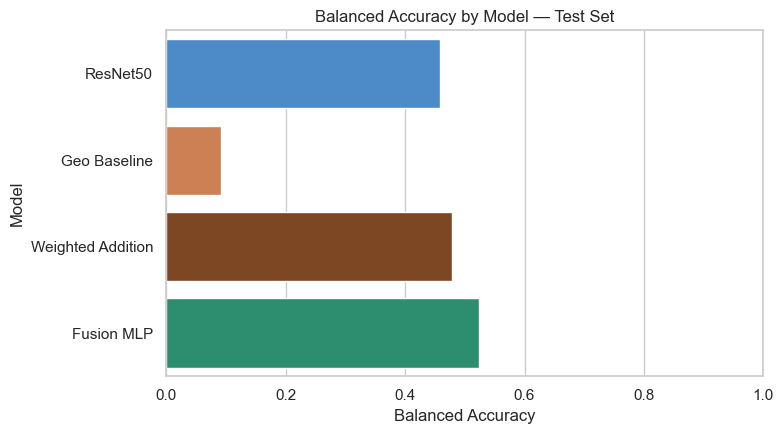

In [12]:
# CONFIG — add new models here, everything else updates automatically.
# This mirrors the plotting setup used in notebook 08.

def as_08_metrics(metrics):
    out = dict(metrics)
    out["acc"] = metrics.get("balanced_accuracy", metrics.get("acc"))
    return out

resnet_val_metrics = as_08_metrics(metrics_from_logits(
    fusion_cache["val"]["image_logits"],
    fusion_cache["val"]["labels"],
    "ResNet50",
))
geo_expanded_val_metrics = as_08_metrics(metrics_from_logits(
    fusion_cache["val"]["geo_logits"],
    fusion_cache["val"]["labels"],
    "Geo Baseline",
))
wa_weighted_val = as_08_metrics(weighted_val_metrics)
fusion_val_metrics = as_08_metrics(fusion_val_metrics)

resnet_test_metrics = as_08_metrics(metrics_from_logits(
    fusion_cache["test"]["image_logits"],
    fusion_cache["test"]["labels"],
    "ResNet50",
))
geo_expanded_test_metrics = as_08_metrics(expanded_geo_test_metrics)
wa_weighted_test = as_08_metrics(weighted_test_metrics)
fusion_test_metrics = as_08_metrics(fusion_test_metrics)

MODELS = [
    {"name": "ResNet50", "metrics": resnet_val_metrics, "color": "#378ADD"},
    {"name": "Geo Baseline", "metrics": geo_expanded_val_metrics, "color": "#E07B3F"},
    {"name": "Weighted Addition", "metrics": wa_weighted_val, "color": "#8B4513"},
    {"name": "Fusion MLP", "metrics": fusion_val_metrics, "color": "#1D9E75"},
]

TEST_MODELS = [
    {"name": "ResNet50", "metrics": resnet_test_metrics, "color": "#378ADD"},
    {"name": "Geo Baseline", "metrics": geo_expanded_test_metrics, "color": "#E07B3F"},
    {"name": "Weighted Addition", "metrics": wa_weighted_test, "color": "#8B4513"},
    {"name": "Fusion MLP", "metrics": fusion_test_metrics, "color": "#1D9E75"},
]

print("── Val vs Test Balanced Accuracy ───────────────────────")
for val_m, test_m in zip(MODELS, TEST_MODELS):
    gap = val_m["metrics"]["acc"] - test_m["metrics"]["acc"]
    print(
        f"  {val_m['name']:<25} "
        f"val: {val_m['metrics']['acc']:.4f}  "
        f"test: {test_m['metrics']['acc']:.4f}  "
        f"gap: {gap:+.4f}"
    )

overall_acc = {model["name"]: model["metrics"]["acc"] for model in TEST_MODELS}
overall_acc_df = pd.DataFrame.from_dict(overall_acc, orient="index", columns=["Balanced Accuracy"])
display(overall_acc_df)

plt.figure(figsize=(8, 4.5))
overall_acc_plot_df = overall_acc_df.reset_index().rename(columns={"index": "Model"})
sns.barplot(
    data=overall_acc_plot_df,
    x="Balanced Accuracy",
    y="Model",
    hue="Model",
    palette={m["name"]: m["color"] for m in TEST_MODELS},
    legend=False,
)
plt.title("Balanced Accuracy by Model — Test Set")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


The Fusion MLP achieved the highest balanced accuracy on the held-out test set (0.524), outperforming weighted addition (0.479), the ResNet50 image baseline (0.459), the expanded geo-only baseline (0.092), and the original geo/time baseline (0.056). On validation, the Fusion MLP reached 0.548 balanced accuracy, which is why some saved notebook-08 figure titles refer to validation-selected or validation-stage results.

For all of these models, we compare more than the overall metric. The confusion matrices show how errors are distributed across the 44 species, while the family and per-species plots help reveal whether geo/time information helps uniformly or only for particular ecological groups.

Saved → /Users/wenchuzhang/Documents/Graduate/Harvard/CS 109B/Project/Canopy/submission_group49_plant_geopriors/results/all_models_confusion_matrices_TEST_main.png


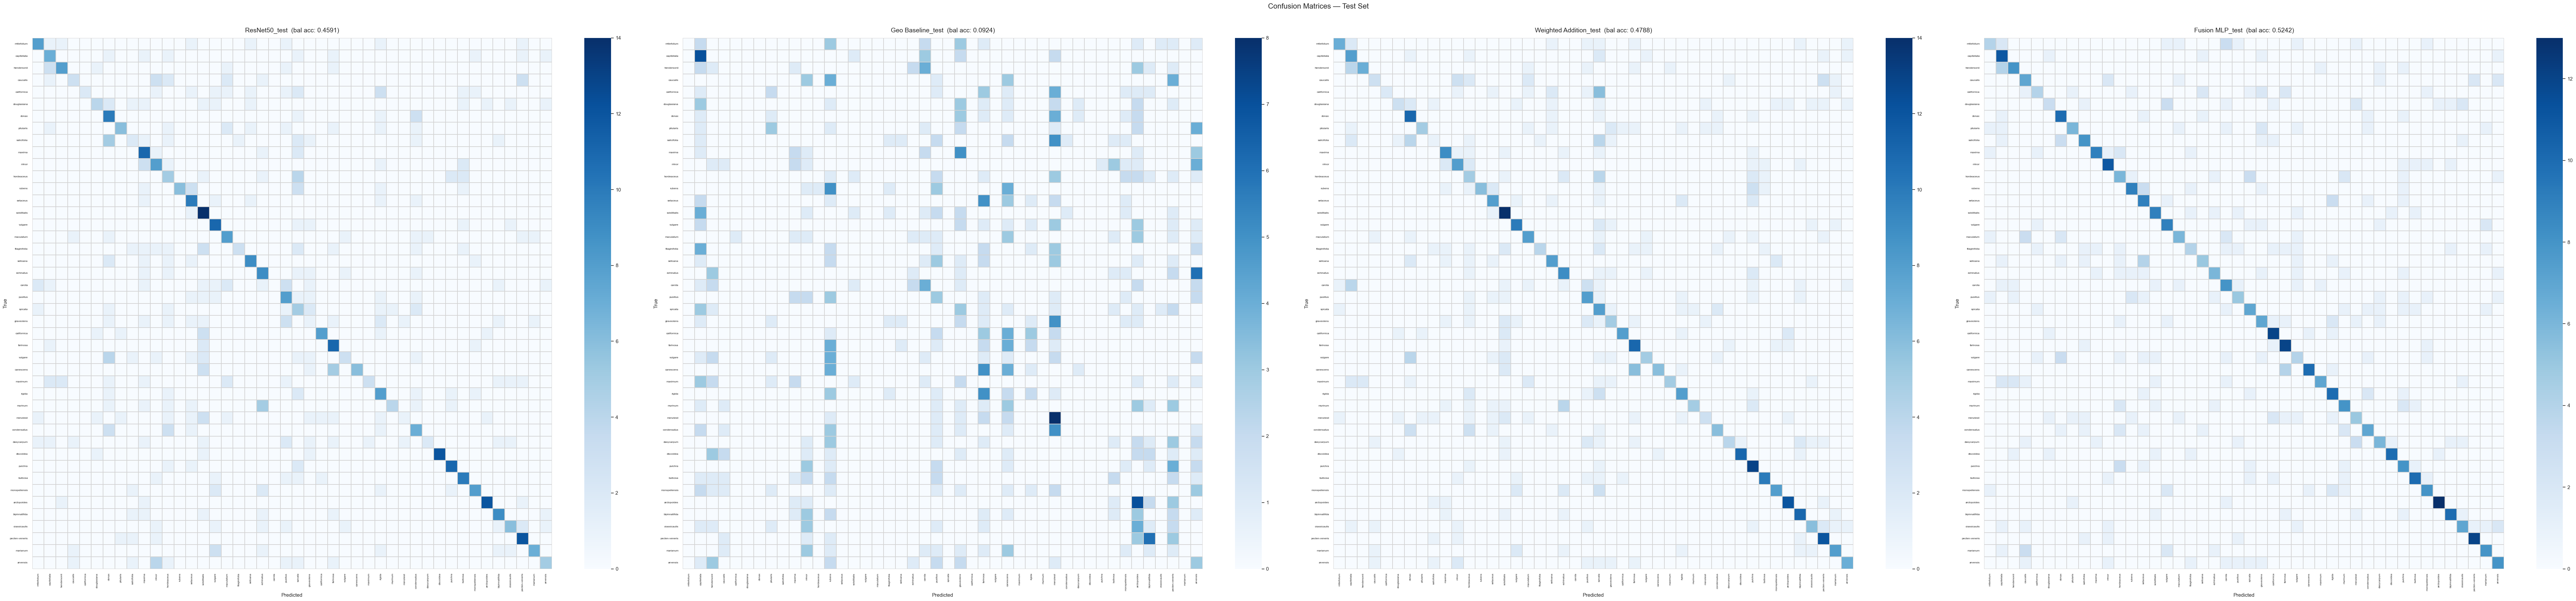

In [13]:
def plot_confusion_matrices_combined(metrics_list, label_encoder, save_path=None, title="Confusion Matrices — Test Set"):
    n = len(metrics_list)
    class_names = [name.split()[-1] for name in label_encoder.classes_]

    fig, axes = plt.subplots(1, n, figsize=(20 * n, 18))
    if n == 1:
        axes = [axes]

    for ax, (metrics, title_text) in zip(axes, metrics_list):
        preds = metrics["preds"].numpy()
        labels = metrics["labels"].numpy()
        cm = confusion_matrix(labels, preds)

        sns.heatmap(
            cm,
            annot=False,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.3,
            linecolor="lightgrey",
            ax=ax,
        )
        acc_str = f"  (bal acc: {metrics['acc']:.4f})" if metrics["acc"] else ""
        ax.set_title(f"{title_text}{acc_str}", fontsize=14, pad=12)
        ax.set_xlabel("Predicted", fontsize=11)
        ax.set_ylabel("True", fontsize=11)
        ax.tick_params(axis="x", rotation=90, labelsize=6)
        ax.tick_params(axis="y", rotation=0, labelsize=6)

    plt.suptitle(title, fontsize=16, y=1.01)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")

    plt.show()


plot_confusion_matrices_combined(
    [
        (resnet_test_metrics, "ResNet50_test"),
        (geo_expanded_test_metrics, "Geo Baseline_test"),
        (wa_weighted_test, "Weighted Addition_test"),
        (fusion_test_metrics, "Fusion MLP_test"),
    ],
    le,
    save_path=RESULTS_DIR / "all_models_confusion_matrices_TEST_main.png",
    title="Confusion Matrices — Test Set",
)


### Per-Family And Per-Species Structure

Saved → /Users/wenchuzhang/Documents/Graduate/Harvard/CS 109B/Project/Canopy/submission_group49_plant_geopriors/results/family_breakdown_TEST_main.png


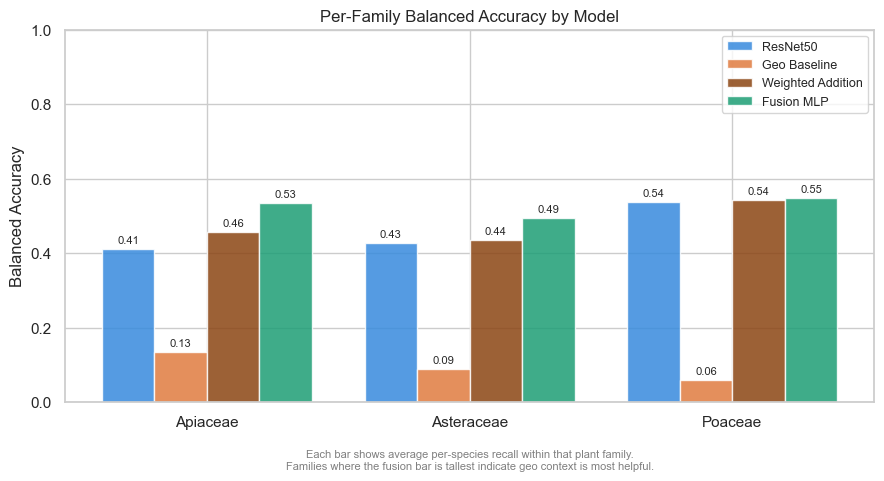

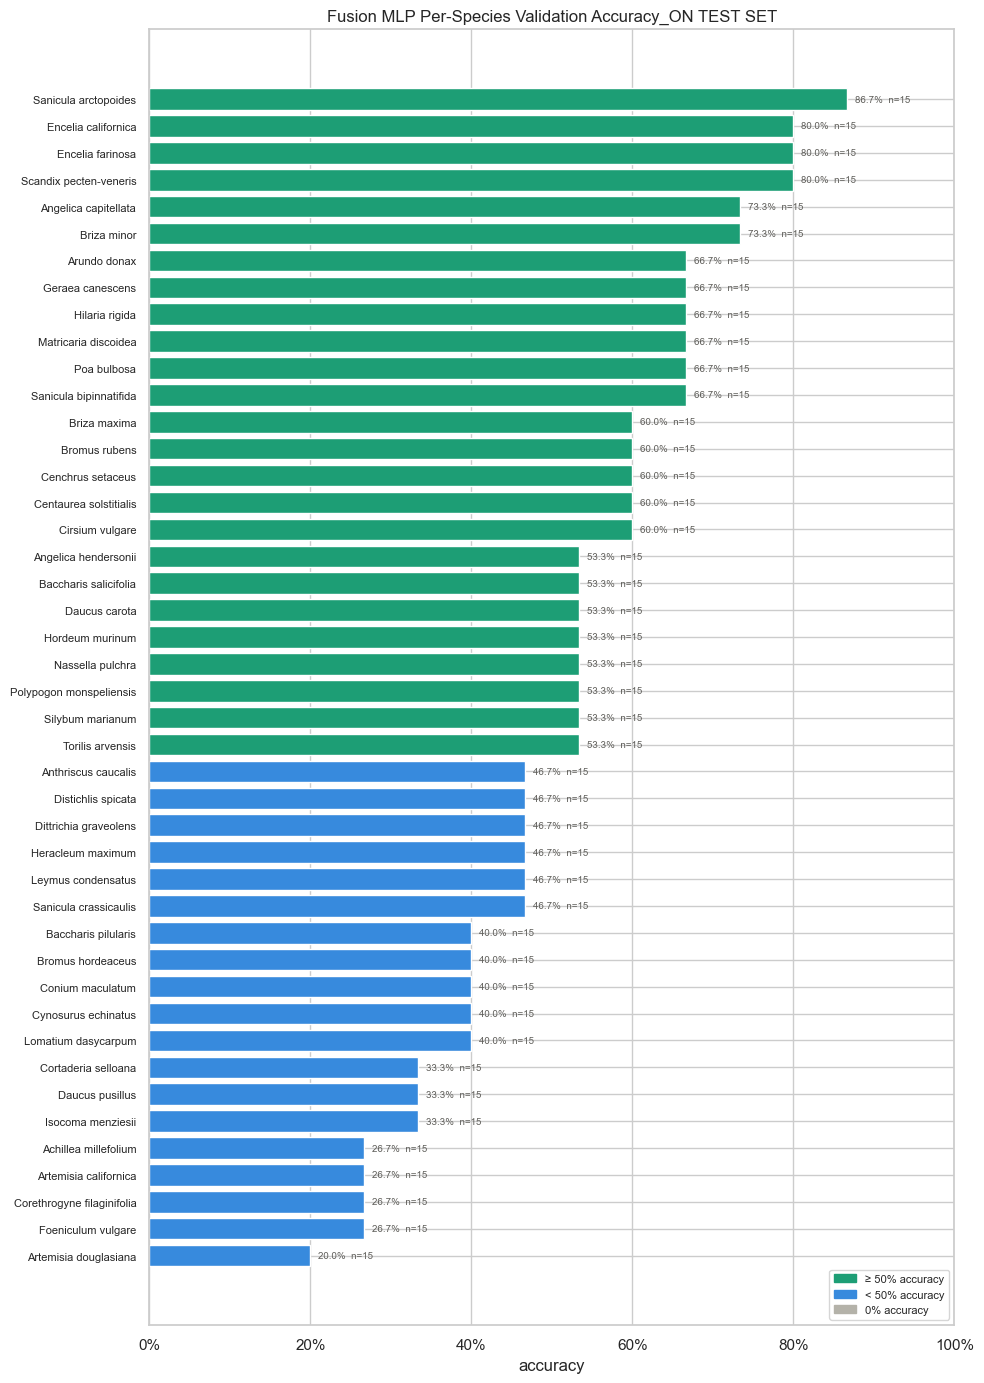

Saved → /Users/wenchuzhang/Documents/Graduate/Harvard/CS 109B/Project/Canopy/submission_group49_plant_geopriors/results/accuracy_delta_TESTSET_main.png


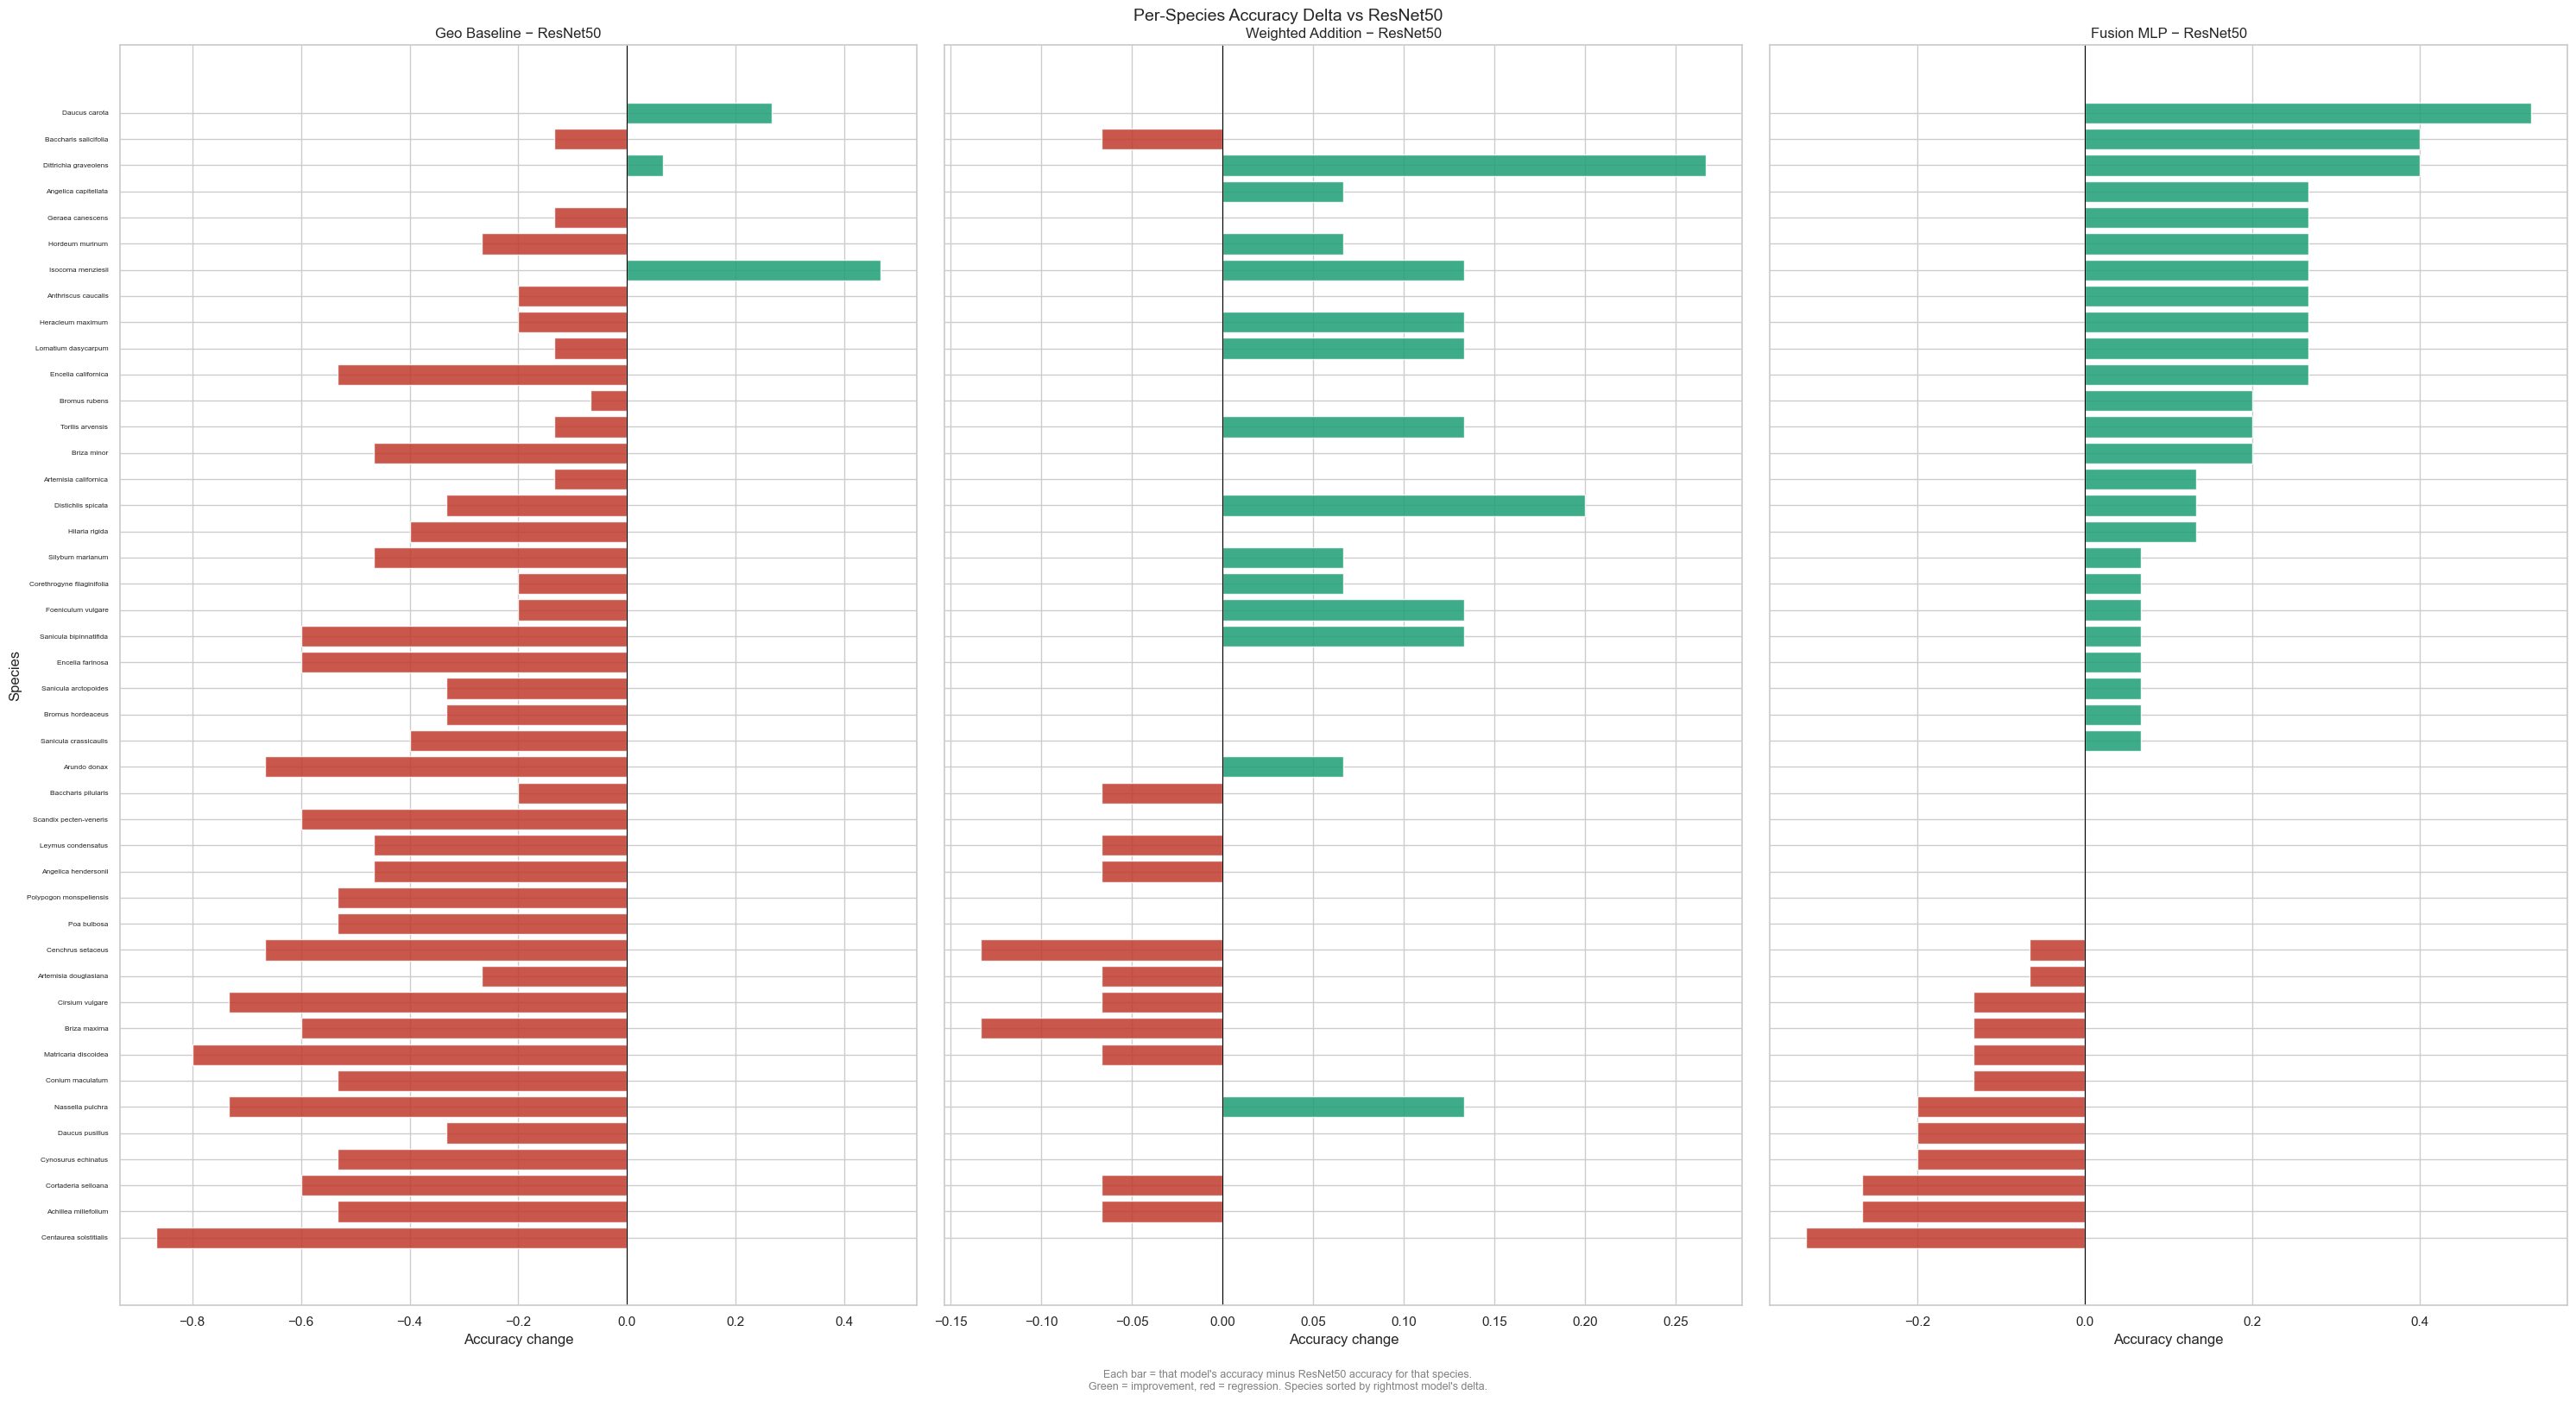

In [14]:
import matplotlib.patches as mpatches

# Family membership for the selected 44 species. We use the exported time-geo species table when available.
time_geo_path = ARTIFACTS_DIR / "time_geo_species_df.csv"
if time_geo_path.exists():
    family_source_df = pd.read_csv(time_geo_path)
    FAMILY_MAP = (
        family_source_df[["species", "family"]]
        .drop_duplicates()
        .set_index("species")["family"]
        .to_dict()
    )
else:
    FAMILY_MAP = {}

missing_family = [sp for sp in le.classes_ if sp not in FAMILY_MAP]
if missing_family:
    print(f"Missing family labels for {len(missing_family)} species; assigning 'Unknown'.")
    for sp in missing_family:
        FAMILY_MAP[sp] = "Unknown"


def plot_family_breakdown(models, label_encoder, family_map, save_path=None):
    """
    Grouped bar chart of balanced accuracy per plant family per model.
    Each group of bars = one family; each bar = one model.
    """
    families = sorted(set(family_map.values()))
    classes = list(label_encoder.classes_)
    x = np.arange(len(families))
    width = 0.8 / len(models)

    fig, ax = plt.subplots(figsize=(9, 5))

    for i, model in enumerate(models):
        preds = model["metrics"]["preds"]
        labels = model["metrics"]["labels"]
        family_accs = []

        for family in families:
            species_in_family = [c for c, f in family_map.items() if f == family]
            idxs = [classes.index(s) for s in species_in_family if s in classes]

            per_species_recall = []
            for idx in idxs:
                mask = labels == idx
                if mask.sum() == 0:
                    continue
                recall = (preds[mask] == idx).float().mean().item()
                per_species_recall.append(recall)

            family_accs.append(np.mean(per_species_recall) if per_species_recall else 0)

        offset = (i - len(models) / 2 + 0.5) * width
        bars = ax.bar(x + offset, family_accs, width, label=model["name"], color=model["color"], alpha=0.85)
        for bar, acc in zip(bars, family_accs):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(families, fontsize=11)
    ax.set_ylabel("Balanced Accuracy")
    ax.set_ylim(0, 1)
    ax.set_title("Per-Family Balanced Accuracy by Model")
    ax.legend(fontsize=9)
    ax.text(
        0.5,
        -0.18,
        "Each bar shows average per-species recall within that plant family.\n"
        "Families where the fusion bar is tallest indicate geo context is most helpful.",
        transform=ax.transAxes,
        ha="center",
        fontsize=8,
        color="grey",
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


plot_family_breakdown(TEST_MODELS, le, FAMILY_MAP, save_path=RESULTS_DIR / "family_breakdown_TEST_main.png")


def per_species_acc_array(metrics):
    preds, labels = metrics["preds"], metrics["labels"]
    accs = []
    for c in range(NUM_CLASSES):
        mask = labels == c
        accs.append((preds[mask] == c).float().mean().item() if mask.sum() > 0 else 0.0)
    return np.array(accs)

def build_species_results(metrics, label_encoder):
    species_results = []
    preds = metrics["preds"]
    labels = metrics["labels"]

    for i in range(len(label_encoder.classes_)):
        correct = int(((preds == labels) & (labels == i)).sum())
        total = int((labels == i).sum())
        species_results.append(
            {
                "name": label_encoder.inverse_transform([i])[0],
                "acc": round(correct / total, 3) if total > 0 else 0,
                "total": total,
                "correct": correct,
            }
        )

    species_results.sort(key=lambda x: x["acc"], reverse=True)
    return species_results


def plot_species_accuracy_bar(species_results, title, save_path=None):
    names = [s["name"] for s in species_results]
    accs = [s["acc"] for s in species_results]
    tots = [s["total"] for s in species_results]

    colors = []
    for a in accs:
        if a == 0:
            colors.append("#B4B2A9")
        elif a >= 0.5:
            colors.append("#1D9E75")
        else:
            colors.append("#378ADD")

    fig, ax = plt.subplots(figsize=(10, 14))
    bars = ax.barh(names, accs, color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel("accuracy")
    ax.set_title(title)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)

    for bar, acc, total in zip(bars, accs, tots):
        if acc > 0:
            ax.text(
                acc + 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{acc:.1%}  n={total}",
                va="center",
                fontsize=7,
                color="#5F5E5A",
            )

    legend_patches = [
        mpatches.Patch(color="#1D9E75", label="≥ 50% accuracy"),
        mpatches.Patch(color="#378ADD", label="< 50% accuracy"),
        mpatches.Patch(color="#B4B2A9", label="0% accuracy"),
    ]
    ax.legend(handles=legend_patches, fontsize=8, loc="lower right")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()


fusion_species_test_results = build_species_results(fusion_test_metrics, le)
plot_species_accuracy_bar(
    fusion_species_test_results,
    "Fusion MLP Per-Species Validation Accuracy_ON TEST SET",
    save_path=RESULTS_DIR / "fusion_mlp_per_species_accuracy_TESTSET.png",
)


def plot_accuracy_delta(models, label_encoder, baseline_name="ResNet50", save_path=None):
    """
    Horizontal bar chart: accuracy of each model MINUS the baseline per species.
    Green bars = model improved over baseline. Red bars = model hurt performance.
    Species sorted by fusion delta.
    """
    classes = list(label_encoder.classes_)
    baseline = next(m for m in models if m["name"] == baseline_name)

    baseline_accs = per_species_acc_array(baseline["metrics"])
    non_baseline = [m for m in models if m["name"] != baseline_name]

    sort_deltas = per_species_acc_array(non_baseline[-1]["metrics"]) - baseline_accs
    order = np.argsort(sort_deltas)
    sorted_names = [classes[i] for i in order]

    fig, axes = plt.subplots(1, len(non_baseline), figsize=(10 * len(non_baseline), 16), sharey=True)
    if len(non_baseline) == 1:
        axes = [axes]

    for ax, model in zip(axes, non_baseline):
        deltas = per_species_acc_array(model["metrics"]) - baseline_accs
        deltas_sorted = deltas[order]
        colors = ["#1D9E75" if d >= 0 else "#C0392B" for d in deltas_sorted]

        ax.barh(sorted_names, deltas_sorted, color=colors, alpha=0.85)
        ax.axvline(0, color="black", linewidth=0.8)
        ax.set_title(f"{model['name']} − {baseline_name}", fontsize=12)
        ax.set_xlabel("Accuracy change")
        ax.tick_params(axis="y", labelsize=6)

    axes[0].set_ylabel("Species")
    fig.suptitle(f"Per-Species Accuracy Delta vs {baseline_name}", fontsize=14)
    fig.text(
        0.5,
        -0.02,
        f"Each bar = that model's accuracy minus {baseline_name} accuracy for that species.\n"
        "Green = improvement, red = regression. Species sorted by rightmost model's delta.",
        ha="center",
        fontsize=9,
        color="grey",
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()


plot_accuracy_delta(TEST_MODELS, le, save_path=RESULTS_DIR / "accuracy_delta_TESTSET_main.png")


If we break down accuracy per family, the story becomes more nuanced. Apiaceae benefits from the fusion methods, while Asteraceae remains competitive under the image-only ResNet50 baseline. Poaceae, the grass family, remains difficult across all modeling approaches.

The geo baseline has weak standalone signal for many species, but it still contributes useful information when combined with the image branch. Under the Fusion MLP, no test species has exactly zero accuracy, whereas the image-only baseline has one zero-accuracy species and the geo-only model has many. This suggests that the fusion head is learning to compensate for weak or uneven geo signal by relying more heavily on image logits when the geographic prior is not informative.

The headline averages also hide substantial per-species variance. The Fusion MLP performs strongly on species such as *Sanicula arctopoides* and *Nassella pulchra*, while species such as *Achillea millefolium* remain challenging. The per-species delta plot makes this tradeoff explicit: weighted addition is more conservative, while the Fusion MLP is more aggressive, producing larger gains for some species and larger regressions for others.

## 8. Error Analysis

This section keeps the species-level deep-dive outputs from `08_Expanded_Baselines_MLP_combination.ipynb` for *Daucus carota*, *Anthriscus caucalis*, and *Centaurea solstitialis*. 


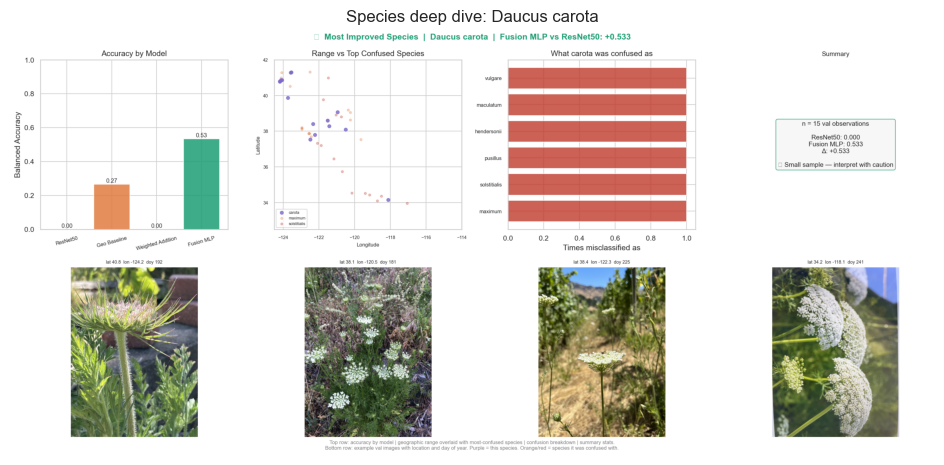

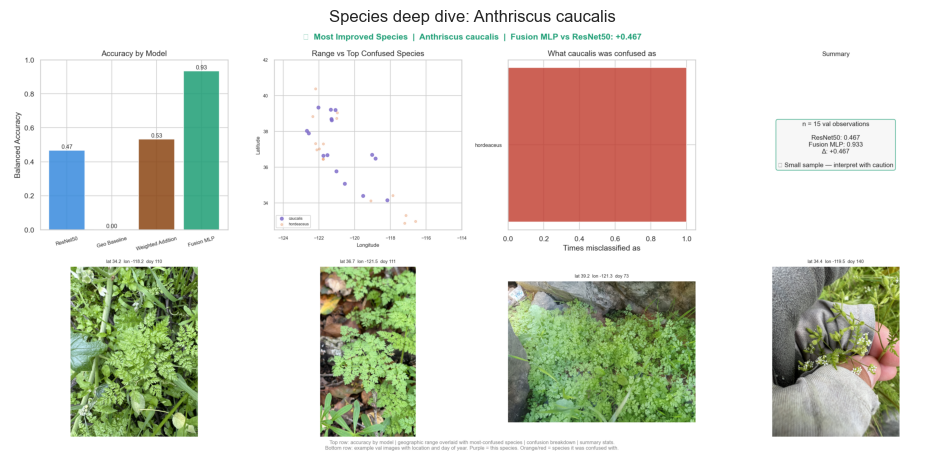

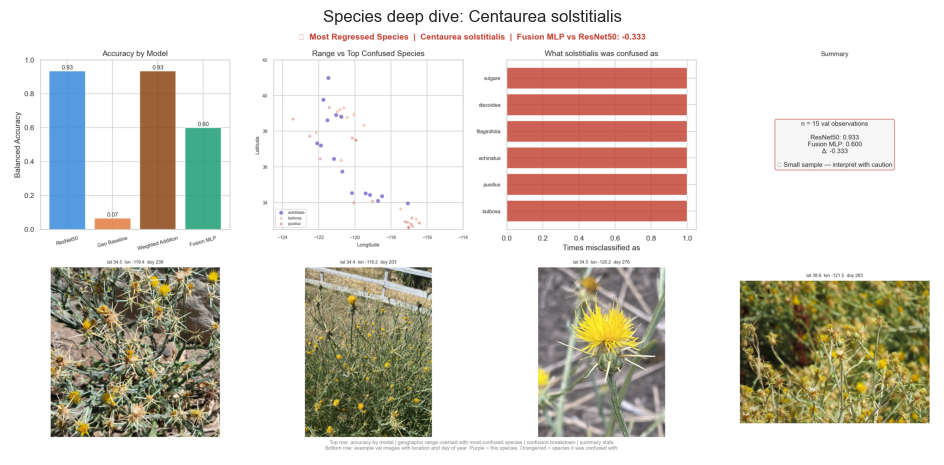

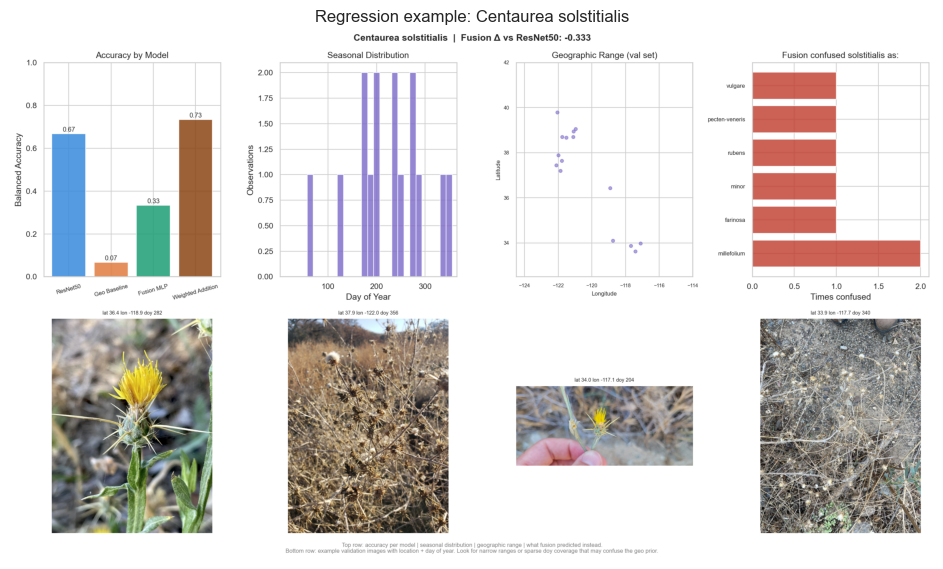

In [15]:
for filename, title in [
    ("improved_Daucus_carota.png", "Species deep dive: Daucus carota"),
    ("improved_Anthriscus_caucalis.png", "Species deep dive: Anthriscus caucalis"),
    ("regressed_Centaurea_solstitialis.png", "Species deep dive: Centaurea solstitialis"),
    ("regression_Centaurea_solstitialis.png", "Regression example: Centaurea solstitialis"),
]:
    show_result_image(filename, title)


### Where Fusion Helps and Where It Hurts

Daucus carota had 0% test accuracy in the image-only ResNet50 baseline and weighted-addition model, but the Fusion MLP improves it to 53.3%. This is a useful example of why a trainable fusion head can outperform a single global weighted average: when the image branch alone carries little usable signal for a species, the learned head can rely more on the geo/time branch.

Anthriscus caucalis shows a similar pattern, improving from 20.0% under ResNet50 to 46.7% under the Fusion MLP. In contrast, Centaurea solstitialis regresses from 93.3% under ResNet50 to 60.0% under Fusion MLP. This species appears to be visually well captured by the image model, so adding the geo branch can introduce noise. These examples show the central tradeoff of geo priors: they help when location and season are discriminative, but can hurt when the visual model is already strong or when species ranges overlap.

## 9. Conclusion

This project demonstrates that geographic and seasonal context can meaningfully improve plant-species classification beyond a strong image-only baseline. Using lightweight sinusoidal geo/time features together with image logits, both late-fusion approaches — weighted addition and the Fusion MLP — consistently outperform the standalone ResNet50 classifier. Among the tested methods, the Fusion MLP achieves the strongest overall performance, suggesting that a learned fusion strategy can better capture complementary information between visual appearance and ecological context.

Our analysis also shows that the value of geographic priors is not uniform across species. Species with localized geographic ranges or strong seasonal patterns benefit the most from fusion, while widespread or visually variable species see smaller gains and occasionally regress under geographic conditioning. This highlights an important limitation of geo priors: they are most effective when species distributions are spatially informative.

The exploratory analysis further revealed several challenges inherent to citizen-science biodiversity datasets, including severe class imbalance and strong geographic sampling bias toward populated and accessible regions. These observations directly influenced our modeling decisions, including the use of weighted cross-entropy loss, per-species sampling caps, and separate geo-expanded datasets for training the geographic backbone.

## 10. Optional Training Entry Points

Training is intentionally disabled in the main run because the checkpoints are already included. The supporting notebooks contain the full training loops:

- `06_EDA_Baseline_Modeling_and_Pipeline_Development.ipynb`: IID split, geo baseline, image baseline.
- `07_weighted_addition_model.ipynb`: validation-set fusion weight search.
- `08_Expanded_Baselines_MLP_combination.ipynb`: expanded geo baseline and Fusion MLP.

Set `RUN_TRAINING = True` only if you want to adapt this notebook into a retraining notebook.

## 11. References And Acknowledgments

**Generative AI assistance.** "Organize and assemble the CS 1090B plant-geopriors main notebook and submission folder" prompt. *OpenAI Codex*, GPT-5, OpenAI, 9 May 2026, https://chat.openai.com/. Used for notebook organization, checkpoint-first evaluation glue code, submission-folder structuring, and cached-logit generation from the team's existing checkpoints; the group reviewed and executed the resulting notebook.

**Data resources.** GBIF.org. "GBIF Occurrence Download." *GBIF.org*, 2025, https://www.gbif.org/. iNaturalist. "iNaturalist Research-Grade Observations." *iNaturalist*, 2025, https://www.inaturalist.org/. The processed observation tables used in this notebook come from the team's California-restricted GBIF/iNaturalist export and filtering pipeline documented in the supporting notebooks.

**Model and software resources.** He, Kaiming, et al. "Deep Residual Learning for Image Recognition." *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 2016, pp. 770-778. TorchVision maintainers. "TorchVision: PyTorch's Computer Vision Library." *PyTorch*, https://pytorch.org/vision/stable/. Accessed 9 May 2026. The image backbone uses the ResNet50 architecture available through TorchVision; this notebook loads the team's saved checkpoints rather than retraining the backbone.